# Problema 4 — Otimização mista da distribuição de canos grossos

Este notebook contém apenas dois casos de teste para o Problema 4:

1. **Caso pequeno/médio:** rede com **20 nós**, para resolver o MILP exato.
2. **Caso grande controlado:** rede com **100 nós** e `edge_prob` pequeno, para gerar poucas arestas e tornar o teste mais viável.

## 1. Importações

Este notebook assume que o arquivo `ProblemaP4.py` está dentro da pasta `src/`, junto com `ProblemaP1.py`, `ProblemaP2.py`, `ProblemaP3.py` e `ProblemGeneratorP1.py`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.ProblemGeneratorP1 import ProblemaP1Generator
from src.ProblemaP4 import ProblemaP4

## 2. Funções auxiliares

As funções abaixo só organizam a visualização dos resultados. Elas não alteram o modelo matemático.

In [2]:
def mostrar_resumo(nome_caso, p1, p4, resumo):
    dados = {
        "caso": nome_caso,
        "nos": p1.num_nodes,
        "arestas": p1.num_edges,
        "canos_grossos_disponiveis": resumo["max_thick_pipes"],
        "canos_grossos_usados": resumo["n_thick_used"],
        "pressao_min": resumo["pressure_min"],
        "pressao_max": resumo["pressure_max"],
        "amplitude_pressao": resumo["objective_pressure_range"],
    }
    return pd.DataFrame([dados])


def tabelas_solucao(p4):
    tabela_nos = pd.DataFrame(p4.node_solution_table())
    tabela_arestas = pd.DataFrame(p4.edge_solution_table())
    tabela_arestas = tabela_arestas.sort_values(
        by=["x_grosso", "delta_pressao"],
        ascending=[False, False],
    )
    return tabela_nos, tabela_arestas


def plotar_solucao(p4, layout="spring", figsize=(10, 8)):
    fig, ax = p4.plot_solution(
        layout=layout,
        figsize=figsize,
        show_labels=False,
        seed=42,
    )
    plt.show()
    return fig, ax

# Caso 1 — MILP exato com 20 nós

Este é o caso principal para apresentação. A rede tem 20 nós e uma quantidade moderada de arestas, permitindo mostrar a solução por otimização mista de forma mais controlada.

In [3]:
SEED_20 = 42
NUM_NODES_20 = 20
EDGE_PROB_20 = 0.10
MAX_THICK_PIPES_20 = 3
THICK_AREA_FACTOR_20 = 2.0

MU = 1e-3
PATM = 0.0
Q_MODE = "uniform"
SINGLE_SINK = True

In [4]:
generator_20 = ProblemaP1Generator(seed=SEED_20)

p1_20 = generator_20.generate(
    num_nodes=NUM_NODES_20,
    edge_prob=EDGE_PROB_20,
    mu=MU,
    patm=PATM,
    q_mode=Q_MODE,
    single_sink=SINGLE_SINK,
)

p1_20.setup()
p1_20.solve()

print(f"nos: {p1_20.num_nodes}")
print(f"arestas: {p1_20.num_edges}")
print(f"pressao minima p1: {min(p1_20.p):.6g}")
print(f"pressao maxima p1: {max(p1_20.p):.6g}")
print(f"amplitude de pressao p1: {max(p1_20.p) - min(p1_20.p):.6g}")

nos: 20
arestas: 35
pressao minima p1: 0
pressao maxima p1: 0.304876
amplitude de pressao p1: 0.304876


In [5]:
p4_20 = ProblemaP4(
    p1_instance=p1_20,
    max_thick_pipes=MAX_THICK_PIPES_20,
    thick_area_factor=THICK_AREA_FACTOR_20,
    use_exact_number=True,
    solver_options={
        "disp": True,
    },
)

resumo_20 = p4_20.solve()
resumo_20

{'objective_pressure_range': 0.11593932261773583,
 'solver_objective': 0.11593932261773583,
 'pressure_min': 0.0,
 'pressure_max': 0.11593932261773583,
 'max_thick_pipes': 3,
 'n_thick_used': 3,
 'selected_thick_edges': [('node_1', 'node_5'),
  ('node_4', 'node_5'),
  ('node_15', 'node_17')]}

In [6]:
mostrar_resumo("20 nos milp exato", p1_20, p4_20, resumo_20)

,caso,nos,arestas,canos_grossos_disponiveis,canos_grossos_usados,pressao_min,pressao_max,amplitude_pressao
0,20 nos milp exato,20,35,3,3,0.0,0.115939,0.115939


In [7]:
tabela_nos_20, tabela_arestas_20 = tabelas_solucao(p4_20)

tabela_nos_20.head()

,node,pressao,fluxo_externo
0,node_0,0.083017,0.329324
1,node_1,0.059160,0.056682
2,node_2,0.074769,0.095837
3,node_3,0.068262,0.109584
4,node_4,0.000000,-3.975101


In [8]:
tabela_arestas_20.head(10)

,edge,tipo_cano,x_grosso,area_original,area_usada,length,condutancia_usada,delta_pressao,vazao
5,"(node_1, node_5)",grosso,1,1.4017,2.8034,3.83,81.645359,0.035665,2.911862
18,"(node_4, node_5)",grosso,1,1.3201,2.6402,1.74,159.398616,-0.023496,-3.745184
32,"(node_15, node_17)",grosso,1,0.7114,1.4228,4.21,19.132237,-0.043110,-0.824793
14,"(node_2, node_4)",fino,0,0.5871,0.5871,4.46,3.075031,0.074769,0.229918
16,"(node_3, node_5)",fino,0,0.8882,0.8882,3.65,8.599809,0.044766,0.384981
34,"(node_17, node_18)",fino,0,0.6118,0.6118,4.95,3.008665,0.025068,0.075423
0,"(node_0, node_1)",fino,0,1.0618,1.0618,4.80,9.345539,0.023856,0.222951
15,"(node_2, node_7)",fino,0,0.5516,0.5516,4.64,2.609100,0.010351,0.027007
24,"(node_9, node_11)",fino,0,1.4178,1.4178,1.56,51.270256,0.008356,0.428427
1,"(node_0, node_2)",fino,0,1.5980,1.5980,3.39,29.971880,0.008248,0.247196


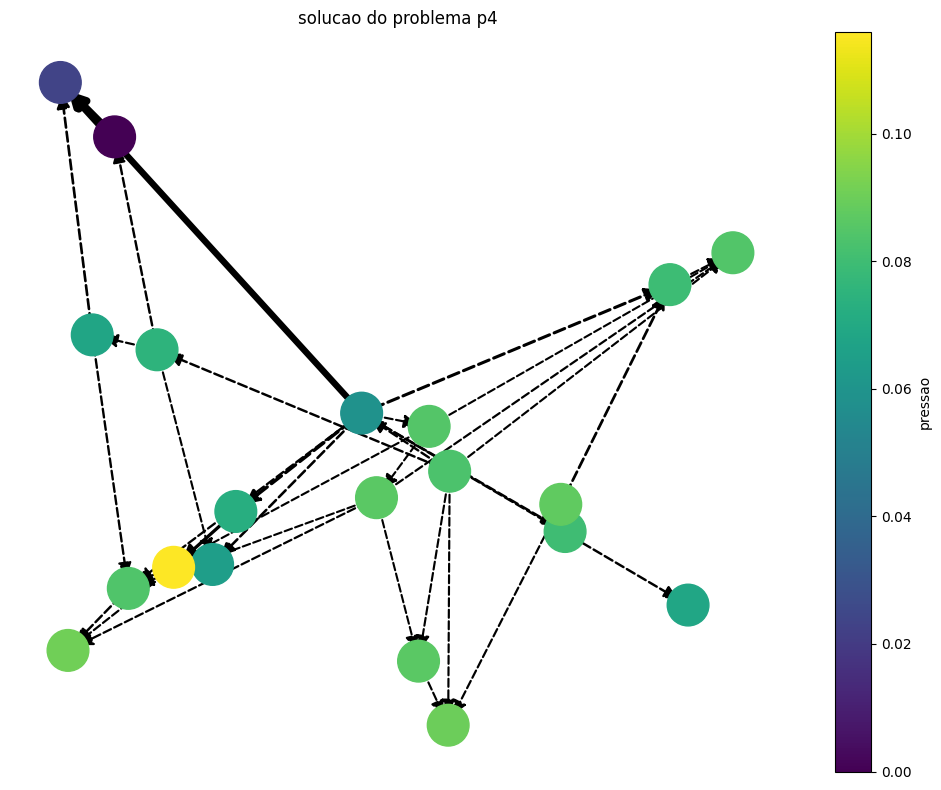

(<Figure size 1000x800 with 2 Axes>,
 <Axes: title={'center': 'solucao do problema p4'}>)

In [9]:
plotar_solucao(p4_20, layout="spring", figsize=(10, 8))

# Caso 2 — 100 nós com poucas arestas

Este caso usa 100 nós, mas reduz bastante `edge_prob`. Como o gerador sempre cria uma árvore conexa antes de adicionar arestas extras, a rede terá pelo menos 99 arestas. Com `edge_prob = 0.005`, a quantidade de arestas extras tende a ser pequena.

O MILP continua sendo mais pesado que o caso de 20 nós, então foi colocado limite de tempo no solver.

In [10]:
SEED_100 = 123
NUM_NODES_100 = 100
EDGE_PROB_100 = 0.005
MAX_THICK_PIPES_100 = 3
THICK_AREA_FACTOR_100 = 2.0
TIME_LIMIT_100 = 300

In [11]:
generator_100 = ProblemaP1Generator(seed=SEED_100)

p1_100 = generator_100.generate(
    num_nodes=NUM_NODES_100,
    edge_prob=EDGE_PROB_100,
    mu=MU,
    patm=PATM,
    q_mode=Q_MODE,
    single_sink=SINGLE_SINK,
)

p1_100.setup()
p1_100.solve()

print(f"nos: {p1_100.num_nodes}")
print(f"arestas: {p1_100.num_edges}")
print(f"pressao minima p1: {min(p1_100.p):.6g}")
print(f"pressao maxima p1: {max(p1_100.p):.6g}")
print(f"amplitude de pressao p1: {max(p1_100.p) - min(p1_100.p):.6g}")

nos: 100
arestas: 119
pressao minima p1: 0
pressao maxima p1: 0.238436
amplitude de pressao p1: 0.238436


In [12]:
p4_100 = ProblemaP4(
    p1_instance=p1_100,
    max_thick_pipes=MAX_THICK_PIPES_100,
    thick_area_factor=THICK_AREA_FACTOR_100,
    use_exact_number=True,
    solver_options={
        "disp": True,
        "time_limit": TIME_LIMIT_100,
    },
)

resumo_100 = p4_100.solve()
resumo_100

{'objective_pressure_range': 0.13564573491618048,
 'solver_objective': 0.13564573491618045,
 'pressure_min': 0.0,
 'pressure_max': 0.13564573491618048,
 'max_thick_pipes': 3,
 'n_thick_used': 3,
 'selected_thick_edges': [('node_0', 'node_6'),
  ('node_3', 'node_4'),
  ('node_4', 'node_17')]}

In [13]:
mostrar_resumo("100 nos com poucas arestas", p1_100, p4_100, resumo_100)

,caso,nos,arestas,canos_grossos_disponiveis,canos_grossos_usados,pressao_min,pressao_max,amplitude_pressao
0,100 nos com poucas arestas,100,119,3,3,0.0,0.135646,0.135646


In [14]:
tabela_nos_100, tabela_arestas_100 = tabelas_solucao(p4_100)

tabela_nos_100.head()

,node,pressao,fluxo_externo
0,node_0,0.067328,0.001164
1,node_1,0.071926,0.102278
2,node_2,0.088602,0.032751
3,node_3,0.042083,0.034892
4,node_4,0.033368,0.024320


In [15]:
tabela_arestas_100.head(10)

,edge,tipo_cano,x_grosso,area_original,area_usada,length,condutancia_usada,delta_pressao,vazao
19,"(node_4, node_17)",grosso,1,1.1463,2.2926,2.97,70.414203,0.033368,2.349568
17,"(node_3, node_4)",grosso,1,1.9711,3.9422,3.74,165.335398,0.008715,1.440892
2,"(node_0, node_6)",grosso,1,1.0148,2.0296,3.92,41.811426,-0.013672,-0.571648
24,"(node_5, node_16)",fino,0,0.6382,0.6382,2.73,5.936235,0.027428,0.162819
1,"(node_0, node_3)",fino,0,1.5792,1.5792,2.69,36.887747,0.025245,0.931238
77,"(node_36, node_98)",fino,0,0.5440,0.5440,3.54,3.326248,0.022100,0.073512
12,"(node_2, node_26)",fino,0,0.6809,0.6809,4.31,4.280057,0.016860,0.072162
32,"(node_8, node_10)",fino,0,1.2973,1.2973,3.13,21.394229,0.013724,0.293619
117,"(node_89, node_98)",fino,0,0.9529,0.9529,4.92,7.343273,0.012189,0.089508
9,"(node_1, node_38)",fino,0,0.5242,0.5242,3.38,3.234726,0.012051,0.038981


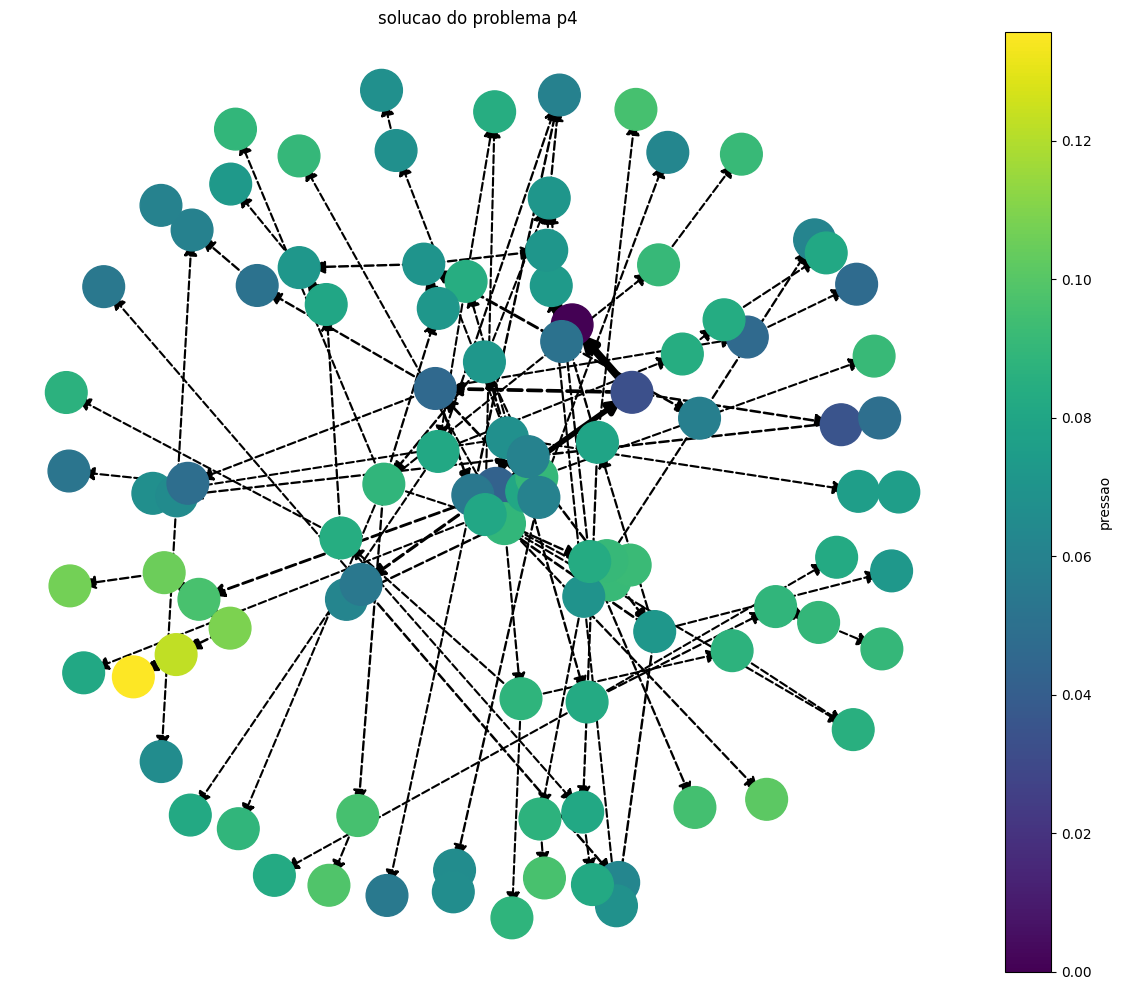

(<Figure size 1200x1000 with 2 Axes>,
 <Axes: title={'center': 'solucao do problema p4'}>)

In [16]:
plotar_solucao(p4_100, layout="spring", figsize=(12, 10))

## Observação para o relatório

O primeiro caso é mais adequado para apresentar a solução exata do MILP. O segundo caso serve para mostrar que o método também pode ser aplicado a redes maiores, desde que a quantidade de arestas seja controlada e que se imponha limite de tempo ao solver.